In [51]:
spark.stop()

In [1]:
from utils import *
spark = initialize_spark_sedona("100g")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/30 05:15:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/30 05:15:18 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Session and SedonaContext have been successfully initiated.


In [2]:
import pandas as pd
pop_to_hh = pd.read_csv('pop_hhcount_nso_w_geom.csv')
pop_to_hh = pop_to_hh[['Province', 'Population_2021', '2022_HH_count', 'Pop_to_HH']]
pop_to_hh['Pop_to_HH'] = pop_to_hh['Pop_to_HH'].round(2)
pop_to_hh

,Province,Population_2021,2022_HH_count,Pop_to_HH
0,bangkok,9102272,3369140,2.70
1,samutprakan,2396310,924779,2.59
2,nonthaburi,1889277,608941,3.10
3,pathumthani,1889029,675573,2.80
4,phranakhonsiayutthaya,920073,311101,2.96
...,...,...,...,...
72,trang,634266,194527,3.26
73,phatthalung,491159,158711,3.09
74,pattani,652332,152469,4.28
75,yala,485872,135391,3.59


In [3]:
quadkeys = spark.read.parquet("s3a://propheus-data-staging/Thailand/Gee_Buildings/quadkey.parquet")
quadkeys.count()

26/01/30 05:15:23 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


1815712

In [4]:
quadkeys.show()

+----------------+--------------------+
|         quadkey|    quadkey_geometry|
+----------------+--------------------+
|1322033111002331|POLYGON ((100.936...|
|1322033110101112|POLYGON ((100.799...|
|1322033110110012|POLYGON ((100.821...|
|1322031332333310|POLYGON ((100.887...|
|1322033110111130|POLYGON ((100.887...|
|1322033110123111|POLYGON ((100.805...|
|1322033110132132|POLYGON ((100.843...|
|1322033110032020|POLYGON ((100.634...|
|1322033110120030|POLYGON ((100.733...|
|1322033110132230|POLYGON ((100.821...|
|1322033110022101|POLYGON ((100.574...|
|1322033101133212|POLYGON ((100.513...|
|1322033110113233|POLYGON ((100.870...|
|1322033111022010|POLYGON ((100.909...|
|1322033110132031|POLYGON ((100.827...|
|1322033110003102|POLYGON ((100.612...|
|1322033110031120|POLYGON ((100.700...|
|1322033110202201|POLYGON ((100.552...|
|1322033110021220|POLYGON ((100.590...|
|1322033110110200|POLYGON ((100.810...|
+----------------+--------------------+
only showing top 20 rows



In [5]:
quadkeys.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- quadkey_geometry: string (nullable = true)



In [7]:
from pyspark.sql.functions import *
quadkeys = quadkeys.withColumn('quadkey_geometry', expr("ST_GeomFromWKT(quadkey_geometry)"))
quadkeys.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- quadkey_geometry: geometry (nullable = true)



In [46]:


quadkeys_with_centroid = quadkeys.withColumn("quadkey_centroid",expr("ST_Centroid(quadkey_geometry)"))
quadkeys_with_centroid.show()

+----------------+--------------------+--------------------+
|         quadkey|    quadkey_geometry|    quadkey_centroid|
+----------------+--------------------+--------------------+
|1322033111002331|POLYGON ((100.936...|POINT (100.939636...|
|1322033110101112|POLYGON ((100.799...|POINT (100.802307...|
|1322033110110012|POLYGON ((100.821...|POINT (100.824279...|
|1322031332333310|POLYGON ((100.887...|POINT (100.890197...|
|1322033110111130|POLYGON ((100.887...|POINT (100.890197...|
|1322033110123111|POLYGON ((100.805...|POINT (100.807800...|
|1322033110132132|POLYGON ((100.843...|POINT (100.846252...|
|1322033110032020|POLYGON ((100.634...|POINT (100.637512...|
|1322033110120030|POLYGON ((100.733...|POINT (100.736389...|
|1322033110132230|POLYGON ((100.821...|POINT (100.824279...|
|1322033110022101|POLYGON ((100.574...|POINT (100.577087...|
|1322033101133212|POLYGON ((100.513...|POINT (100.516662...|
|1322033110113233|POLYGON ((100.870...|POINT (100.873718...|
|1322033111022010|POLYGO

In [49]:
quadkeys_with_centroid = quadkeys_with_centroid.distinct()
quadkeys_with_centroid.count()

1606681

In [50]:
adm3_geom = spark.read.parquet('admin3_geom')
adm3_geom_req = adm3_geom.filter((col('adm1_name') == 'Bangkok') | (col('adm1_name') == 'Chiang Mai') | (col('adm1_name') == 'Nakhon Ratchasima'))
adm3_geom_req.show()

+-------------+--------------------+-----------------+--------------------+
|    adm3_name|           adm2_name|        adm1_name|            geometry|
+-------------+--------------------+-----------------+--------------------+
|   Nai Mueang|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.136...|
|    Pho Klang|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.111...|
|  Nong Chabok|Mueang Nakhon Rat...|Nakhon Ratchasima|MULTIPOLYGON (((1...|
|    Khok Sung|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.115...|
|      Maroeng|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.170...|
| Nong Rawiang|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.214...|
|      Pru Yai|Mueang Nakhon Rat...|Nakhon Ratchasima|MULTIPOLYGON (((1...|
|     Muen Wai|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.098...|
|   Phon Krang|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.010...|
|Nong Phai Lom|Mueang Nakhon Rat...|Nakhon Ratchasima|POLYGON ((102.094...|
|    Hua Tha

In [78]:
quad_keys_w_geom_req = quadkeys_with_centroid.alias("a").join(
    adm3_geom_req.alias("b"),
    expr("ST_Contains(b.geometry, a.quadkey_centroid)"),
    "inner"
)
quad_keys_w_geom_req.write.mode("overwrite").parquet("quadkeys_w_subdistrict_3_provinces")                                           

26/01/30 06:41:26 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.
                                                                                

In [80]:
quad_keys_w_geom_req = spark.read.parquet("quadkeys_w_subdistrict")     
quad_keys_w_geom_req.count()

130699

In [81]:
quad_keys_w_geom_req = quad_keys_w_geom_req.withColumn("adm1_name", lower(col('adm1_name'))) \
                    .withColumn("adm1_name", regexp_replace(col('adm1_name'), " ", ""))
quad_keys_w_geom_req.show()

+----------------+--------------------+--------------------+----------+-------------+----------------+--------------------+
|         quadkey|    quadkey_geometry|    quadkey_centroid| adm3_name|    adm2_name|       adm1_name|            geometry|
+----------------+--------------------+--------------------+----------+-------------+----------------+--------------------+
|1322120201011312|POLYGON ((101.766...|POINT (101.769104...|Kut Phiman|Dan Khun Thot|nakhonratchasima|POLYGON ((101.771...|
|1322120201011231|POLYGON ((101.749...|POINT (101.752624...|Kut Phiman|Dan Khun Thot|nakhonratchasima|POLYGON ((101.771...|
|1322120201011320|POLYGON ((101.755...|POINT (101.758117...|Kut Phiman|Dan Khun Thot|nakhonratchasima|POLYGON ((101.771...|
|1322120201010132|POLYGON ((101.722...|POINT (101.725158...|Kut Phiman|Dan Khun Thot|nakhonratchasima|POLYGON ((101.771...|
|1322120201011302|POLYGON ((101.755...|POINT (101.758117...|Kut Phiman|Dan Khun Thot|nakhonratchasima|POLYGON ((101.771...|
|1322120

In [54]:
pop_to_hh_spark = spark.createDataFrame(pop_to_hh)
pop_to_hh_spark.show()

+--------------------+---------------+-------------+---------+
|            Province|Population_2021|2022_HH_count|Pop_to_HH|
+--------------------+---------------+-------------+---------+
|             bangkok|        9102272|      3369140|      2.7|
|         samutprakan|        2396310|       924779|     2.59|
|          nonthaburi|        1889277|       608941|      3.1|
|         pathumthani|        1889029|       675573|      2.8|
|phranakhonsiayutt...|         920073|       311101|     2.96|
|            angthong|         242466|        82287|     2.95|
|             lopburi|         768859|       266958|     2.88|
|            singburi|         182009|        62131|     2.93|
|             chainat|         285449|       101490|     2.81|
|            saraburi|         767673|       253998|     3.02|
|            chonburi|        2042884|       690875|     2.96|
|              rayong|        1144396|       401393|     2.85|
|         chanthaburi|         577744|       190627|   

In [82]:
quad_keys_w_geom_req = quad_keys_w_geom_req.join(
    pop_to_hh_spark,
    quad_keys_w_geom_req.adm1_name == pop_to_hh_spark.Province,
    how = 'inner'
).select(quad_keys_w_geom_req['*'], pop_to_hh_spark.Pop_to_HH)
quad_keys_w_geom_req.persist()
quad_keys_w_geom_req.show()

+----------------+--------------------+--------------------+--------------------+--------------+---------+--------------------+---------+
|         quadkey|    quadkey_geometry|    quadkey_centroid|           adm3_name|     adm2_name|adm1_name|            geometry|Pop_to_HH|
+----------------+--------------------+--------------------+--------------------+--------------+---------+--------------------+---------+
|1322033110023203|POLYGON ((100.596...|POINT (100.599060...|      Wang Thonglang|Wang Thonglang|  bangkok|POLYGON ((100.609...|      2.7|
|1322033110023200|POLYGON ((100.590...|POINT (100.593566...|      Wang Thonglang|Wang Thonglang|  bangkok|POLYGON ((100.609...|      2.7|
|1322033110023201|POLYGON ((100.596...|POINT (100.599060...|      Wang Thonglang|Wang Thonglang|  bangkok|POLYGON ((100.609...|      2.7|
|1322033110023023|POLYGON ((100.596...|POINT (100.599060...|      Wang Thonglang|Wang Thonglang|  bangkok|POLYGON ((100.609...|      2.7|
|1322033110023020|POLYGON ((100.59

26/01/30 06:41:59 WARN CacheManager: Asked to cache already cached data.


In [83]:
quad_keys_w_geom_req.select(col('adm1_name'), col('Pop_to_HH')).distinct().show()

+----------------+---------+
|       adm1_name|Pop_to_HH|
+----------------+---------+
|         bangkok|      2.7|
|       chiangmai|     2.69|
|nakhonratchasima|     3.18|
+----------------+---------+



In [84]:
quad_keys_w_geom_req = quad_keys_w_geom_req.withColumn("Pop_to_HH_u_limit", round(col('Pop_to_HH')+2*lit(0.29), 2)) \
                                .withColumn("Pop_to_HH_l_limit", round(col('Pop_to_HH')-2*lit(0.29), 2))
quad_keys_w_geom_req.show()

+----------------+--------------------+--------------------+--------------------+--------------+---------+--------------------+---------+-----------------+-----------------+
|         quadkey|    quadkey_geometry|    quadkey_centroid|           adm3_name|     adm2_name|adm1_name|            geometry|Pop_to_HH|Pop_to_HH_u_limit|Pop_to_HH_l_limit|
+----------------+--------------------+--------------------+--------------------+--------------+---------+--------------------+---------+-----------------+-----------------+
|1322033110023203|POLYGON ((100.596...|POINT (100.599060...|      Wang Thonglang|Wang Thonglang|  bangkok|POLYGON ((100.609...|      2.7|             3.28|             2.12|
|1322033110023200|POLYGON ((100.590...|POINT (100.593566...|      Wang Thonglang|Wang Thonglang|  bangkok|POLYGON ((100.609...|      2.7|             3.28|             2.12|
|1322033110023201|POLYGON ((100.596...|POINT (100.599060...|      Wang Thonglang|Wang Thonglang|  bangkok|POLYGON ((100.609...|   

In [58]:
pop_to_hh.describe()

,Population_2021,2022_HH_count,Pop_to_HH
count,7.700000e+01,7.700000e+01,77.000000
mean,9.114271e+05,3.062050e+05,3.059870
std,1.080746e+06,3.971657e+05,0.290714
min,1.743250e+05,5.843900e+04,2.590000
25%,4.358950e+05,1.397310e+05,2.880000
50%,6.814700e+05,2.129760e+05,3.050000
75%,1.025206e+06,3.237840e+05,3.200000
max,9.102272e+06,3.369140e+06,4.280000


In [60]:
quad_keys_w_geom_bangkok = quad_keys_w_geom.filter(col('adm1_name') == 'bangkok')
quad_keys_w_geom_chiangmai = quad_keys_w_geom.filter(col('adm1_name') == 'chiangmai')
quad_keys_w_geom_nakhonratchasima = quad_keys_w_geom.filter(col('adm1_name') == 'nakhonratchasima')
quad_keys_w_geom_bangkok.count() , quad_keys_w_geom_chiangmai.count() , quad_keys_w_geom_nakhonratchasima.count()

(4479, 66524, 59696)

In [73]:
bangkok_u_limit = quad_keys_w_geom_bangkok.select(col('Pop_to_HH_u_limit')).distinct().collect()[0][0]
bangkok_l_limit = quad_keys_w_geom_bangkok.select(col('Pop_to_HH_l_limit')).distinct().collect()[0][0]

chiangmai_u_limit = quad_keys_w_geom_chiangmai.select(col('Pop_to_HH_u_limit')).distinct().collect()[0][0]
chiangmai_l_limit = quad_keys_w_geom_chiangmai.select(col('Pop_to_HH_l_limit')).distinct().collect()[0][0]

nakhonratchasima_u_limit = quad_keys_w_geom_nakhonratchasima.select(col('Pop_to_HH_u_limit')).distinct().collect()[0][0]
nakhonratchasima_l_limit = quad_keys_w_geom_nakhonratchasima.select(col('Pop_to_HH_l_limit')).distinct().collect()[0][0]

bangkok_u_limit, bangkok_l_limit, chiangmai_u_limit, chiangmai_l_limit, nakhonratchasima_u_limit, nakhonratchasima_l_limit, 

(3.28, 2.12, 3.27, 2.11, 3.76, 2.6)

In [90]:
quadkey_buil_floor_area = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Gee_Buildings/quadkey_buildings_metric.parquet")

DataFrame[quadkey: string, sum_floor_area_sqm: double]

In [91]:
quadkey_buil_floor_area_req.persist()
quadkey_buil_floor_area_req.count()

26/01/30 06:51:40 WARN DAGScheduler: Broadcasting large task binary with size 6.0 MiB
26/01/30 06:51:41 WARN DAGScheduler: Broadcasting large task binary with size 6.0 MiB
                                                                                

77017

In [114]:
quad_keys_w_geom_req_w_buil = quad_keys_w_geom_req.alias('q').join(
    quadkey_buil_floor_area.alias('b'),
    col('q.quadkey') == col('b.quadkey'),
    'inner'
).select(
    col('q.*'),
    col('b.sum_floor_area_sqm').alias('sum_floor_area_sqm')
)
quad_keys_w_geom_req_w_buil.count()

77017

In [101]:
quad_keys_w_geom_req_w_buildings = quadkey_buil_floor_area_req.join(
    quad_keys_w_geom_req,
    quadkey_buil_floor_area_req.quadkey == quad_keys_w_geom_req.quadkey,
    "inner"
)
quad_keys_w_geom_req_w_buildings.count()

77017

In [105]:
quad_keys_w_geom_req_w_buil_bangkok = quad_keys_w_geom_req_w_buil.filter(col('adm1_name') == 'bangkok')
quad_keys_w_geom_req_w_buil_chiangmai = quad_keys_w_geom_req_w_buil.filter(col('adm1_name') == 'chiangmai')
quad_keys_w_geom_req_w_buil_nakhonratchasima = quad_keys_w_geom_req_w_buil.filter(col('adm1_name') == 'nakhonratchasima')
quad_keys_w_geom_req_w_buil_bangkok.count(), quad_keys_w_geom_req_w_buil_chiangmai.count(), quad_keys_w_geom_req_w_buil_nakhonratchasima.count()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


(4432, 31752, 40833)

In [117]:
quad_keys_w_geom_req_w_buil.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- quadkey_geometry: geometry (nullable = true)
 |-- quadkey_centroid: geometry (nullable = true)
 |-- adm3_name: string (nullable = true)
 |-- adm2_name: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- geometry: geometry (nullable = true)
 |-- Pop_to_HH: double (nullable = true)
 |-- Pop_to_HH_u_limit: double (nullable = true)
 |-- Pop_to_HH_l_limit: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)



In [118]:
quad_keys_w_geom_req_w_buil_bangkok = quad_keys_w_geom_req_w_buil.filter(col('adm1_name') == 'bangkok').orderBy(col('sum_floor_area_sqm').desc())
quad_keys_w_geom_req_w_buil_chiangmai = quad_keys_w_geom_req_w_buil.filter(col('adm1_name') == 'chiangmai').orderBy(col('sum_floor_area_sqm').desc())
quad_keys_w_geom_req_w_buil_nakhonratchasima = quad_keys_w_geom_req_w_buil.filter(col('adm1_name') == 'nakhonratchasima').orderBy(col('sum_floor_area_sqm').desc())
quad_keys_w_geom_req_w_buil_bangkok.count(), quad_keys_w_geom_req_w_buil_chiangmai.count(), quad_keys_w_geom_req_w_buil_nakhonratchasima.count()

(4432, 31752, 40833)

In [122]:
import random

random.seed(42)
sampled_values_bangkok = sorted([
    random.uniform(bangkok_l_limit, bangkok_u_limit)
    for _ in range(4432)
])
random.seed(41)
sampled_values_chiangmai = sorted([
    random.uniform(chiangmai_l_limit, chiangmai_u_limit)
    for _ in range(31752)
])
random.seed(40)
sampled_values_nakhonratchasima = sorted([
    random.uniform(nakhonratchasima_l_limit, nakhonratchasima_u_limit)
    for _ in range(40833)
])


In [135]:
from pyspark.sql.functions import row_number, lit
from pyspark.sql.window import Window

w = Window.orderBy(lit(1))

# ========== BANGKOK ==========
quad_keys_w_geom_req_w_buil_bangkok = (
    quad_keys_w_geom_req_w_buil_bangkok
    .withColumn("row_num", row_number().over(w))
)

sampled_bkk_df = spark.createDataFrame(
    list(enumerate(sampled_values_bangkok, start=1)),
    ["row_num", "sampled_value"]
)

bangkok_df = (
    quad_keys_w_geom_req_w_buil_bangkok
    .join(sampled_bkk_df, on="row_num", how="inner")
    .drop("row_num")
)
bangkok_df.persist()

# ========== CHIANG MAI ==========
quad_keys_w_geom_req_w_buil_chiangmai = (
    quad_keys_w_geom_req_w_buil_chiangmai
    .withColumn("row_num", row_number().over(w))
)

sampled_cmn_df = spark.createDataFrame(
    list(enumerate(sampled_values_chiangmai, start=1)),
    ["row_num", "sampled_value"]
)

chiangmai_df = (
    quad_keys_w_geom_req_w_buil_chiangmai
    .join(sampled_cmn_df, on="row_num", how="inner")
    .drop("row_num")
)
chiangmai_df.persist()

# ========== NAKHON RATCHASIMA ==========
quad_keys_w_geom_req_w_buil_nakhonratchasima = (
    quad_keys_w_geom_req_w_buil_nakhonratchasima
    .withColumn("row_num", row_number().over(w))
)

sampled_nakhon_df = spark.createDataFrame(
    list(enumerate(sampled_values_nakhonratchasima, start=1)),
    ["row_num", "sampled_value"]
)

nakhon_df = (
    quad_keys_w_geom_req_w_buil_nakhonratchasima
    .join(sampled_nakhon_df, on="row_num", how="inner")
    .drop("row_num")
)
nakhon_df.persist()


26/01/30 08:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


DataFrame[quadkey: string, quadkey_geometry: udt, quadkey_centroid: udt, adm3_name: string, adm2_name: string, adm1_name: string, geometry: udt, Pop_to_HH: double, Pop_to_HH_u_limit: double, Pop_to_HH_l_limit: double, sum_floor_area_sqm: double, sampled_value: double]

In [136]:
bangkok_df.count(), chiangmai_df.count(), nakhon_df.count()

26/01/30 08:26:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 08:26:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/30 0

(4432, 31752, 40833)

In [137]:
pop_quadtile = spark.read.parquet('abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Population_filtered/thailand_population_quadkey_indexed.parquet')
pop_quadtile = pop_quadtile.groupby(col('qk16')).agg(sum(col('tha_general_2020')).alias("Quadkey_Pop"))
pop_quadtile.show()

+----------------+------------------+
|            qk16|       Quadkey_Pop|
+----------------+------------------+
|1322120122120110|         32.218992|
|1322120033120001|          2.242451|
|1322031122121103| 151.1293869999998|
|1322120033031013|24.215984999999996|
|1322031133021012|14.585018000000002|
|1322120132120013| 37.33065000000001|
|1322120032130102|           2.70122|
|1322120122120030|23.269271999999994|
|1322121122030123|11.764437999999998|
|1322031032131211|           4.33782|
|1322031133131311| 97.75779199999994|
|1322031123031200|29.072247999999988|
|1322120023130312|          5.253534|
|1322121022130220|16.982575999999998|
|1322121023020230|15.074513999999999|
|1322120032130230|21.609759999999998|
|1322121032131331|          6.209976|
|1322120133131331|          4.655402|
|1322120033030223| 94.17327499999998|
|1322120033121323|         21.102021|
+----------------+------------------+
only showing top 20 rows



In [157]:
assert bangkok_df.columns == chiangmai_df.columns == nakhon_df.columns, "Schema mismatch: column names/order differ between dataframes"
final_df = bangkok_df.unionByName(chiangmai_df).unionByName(nakhon_df)

final_df_w_pop = final_df.join(
    pop_quadtile,
    final_df.quadkey == pop_quadtile.qk16,
    "inner"
)
final_df_w_pop.count()

56313

In [158]:
final_df_w_pop.columns

['quadkey',
 'quadkey_geometry',
 'quadkey_centroid',
 'adm3_name',
 'adm2_name',
 'adm1_name',
 'geometry',
 'Pop_to_HH',
 'Pop_to_HH_u_limit',
 'Pop_to_HH_l_limit',
 'sum_floor_area_sqm',
 'sampled_value',
 'qk16',
 'Quadkey_Pop']

In [159]:
final_df_w_pop.filter(col('adm1_name') == 'bangkok').count(), final_df_w_pop.filter(col('adm1_name') == 'chiangmai').count(), final_df_w_pop.filter(col('adm1_name') == 'nakhonratchasima').count()

(4280, 20562, 31471)

In [160]:
quad_keys_w_geom_bangkok.count() , quad_keys_w_geom_chiangmai.count() , quad_keys_w_geom_nakhonratchasima.count()

(4479, 66524, 59696)

In [161]:
final_df_w_pop = final_df_w_pop.withColumn('Qk16_HH_count', col('Quadkey_Pop')/col('sampled_value'))
final_df_w_pop.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- quadkey_geometry: geometry (nullable = true)
 |-- quadkey_centroid: geometry (nullable = true)
 |-- adm3_name: string (nullable = true)
 |-- adm2_name: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- geometry: geometry (nullable = true)
 |-- Pop_to_HH: double (nullable = true)
 |-- Pop_to_HH_u_limit: double (nullable = true)
 |-- Pop_to_HH_l_limit: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- sampled_value: double (nullable = true)
 |-- qk16: string (nullable = true)
 |-- Quadkey_Pop: double (nullable = true)
 |-- Qk16_HH_count: double (nullable = true)



In [162]:
final_df_w_pop.filter(col('adm1_name') == 'bangkok').select(sum(col('Qk16_HH_count'))).show()
final_df_w_pop.filter(col('adm1_name') == 'chiangmai').select(sum(col('Qk16_HH_count'))).show()
final_df_w_pop.filter(col('adm1_name') == 'nakhonratchasima').select(sum(col('Qk16_HH_count'))).show()

+------------------+
|sum(Qk16_HH_count)|
+------------------+
|4006522.3663205435|
+------------------+

+------------------+
|sum(Qk16_HH_count)|
+------------------+
| 834680.8862487916|
+------------------+

+------------------+
|sum(Qk16_HH_count)|
+------------------+
|  830368.767142074|
+------------------+



In [163]:
    pop_to_hh[(pop_to_hh['Province'] == 'bangkok') | (pop_to_hh['Province'] == 'chiangmai') |(pop_to_hh['Province'] == 'nakhonratchasima')]

,Province,Population_2021,2022_HH_count,Pop_to_HH
0,bangkok,9102272,3369140,2.70
26,chiangmai,1786994,663111,2.69
43,nakhonratchasima,2486343,782007,3.18


In [164]:
final_df_w_pop.columns

['quadkey',
 'quadkey_geometry',
 'quadkey_centroid',
 'adm3_name',
 'adm2_name',
 'adm1_name',
 'geometry',
 'Pop_to_HH',
 'Pop_to_HH_u_limit',
 'Pop_to_HH_l_limit',
 'sum_floor_area_sqm',
 'sampled_value',
 'qk16',
 'Quadkey_Pop',
 'Qk16_HH_count']

In [166]:
final_df_w_pop = final_df_w_pop.withColumn('sum_floor_area_sqm(%)', col('sum_floor_area_sqm')*100/360000)
final_df_w_pop.show()

[Stage 1662:=====================================>                  (2 + 1) / 3]

+----------------+--------------------+--------------------+-----------+-----------+---------+--------------------+---------+-----------------+-----------------+------------------+------------------+----------------+------------------+------------------+---------------------+
|         quadkey|    quadkey_geometry|    quadkey_centroid|  adm3_name|  adm2_name|adm1_name|            geometry|Pop_to_HH|Pop_to_HH_u_limit|Pop_to_HH_l_limit|sum_floor_area_sqm|     sampled_value|            qk16|       Quadkey_Pop|     Qk16_HH_count|sum_floor_area_sqm(%)|
+----------------+--------------------+--------------------+-----------+-----------+---------+--------------------+---------+-----------------+-----------------+------------------+------------------+----------------+------------------+------------------+---------------------+
|1322011212201302|POLYGON ((99.2065...|POINT (99.2092895...|     Mae Ai|     Mae Ai|chiangmai|POLYGON ((99.1696...|     2.69|             3.27|             2.11|495.4432

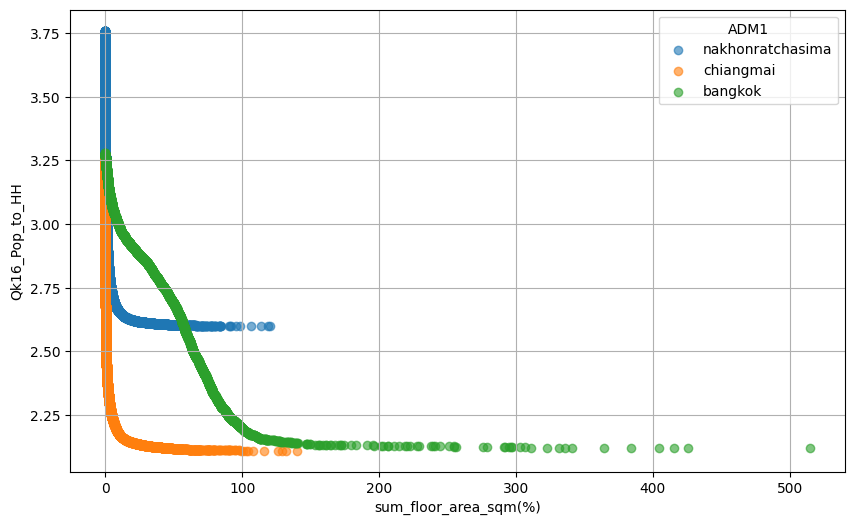

In [167]:
import matplotlib.pyplot as plt

# Select only needed columns and move to pandas
pdf = final_df_w_pop.select(
    "adm1_name",
    "sum_floor_area_sqm(%)",
    "sampled_value"
).toPandas()

plt.figure(figsize=(10, 6))

for adm1 in pdf["adm1_name"].unique():
    subset = pdf[pdf["adm1_name"] == adm1]
    plt.scatter(
        subset["sum_floor_area_sqm(%)"],
        subset["sampled_value"],
        label=adm1,
        alpha=0.6
    )

plt.xlabel("sum_floor_area_sqm(%)")
plt.ylabel("Qk16_Pop_to_HH")
plt.legend(title="ADM1")
plt.grid(True)
plt.show()


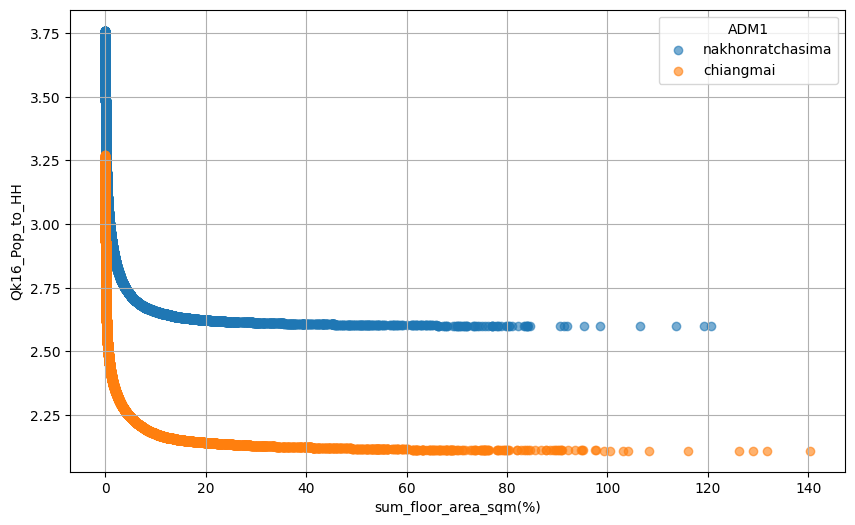

In [168]:
import matplotlib.pyplot as plt

# Select only needed columns and move to pandas
pdf = final_df_w_pop.select(
    "adm1_name",
    "sum_floor_area_sqm(%)",
    "sampled_value"
).toPandas()

plt.figure(figsize=(10, 6))

for adm1 in pdf["adm1_name"].unique():
    if adm1 == 'bangkok': continue
    subset = pdf[pdf["adm1_name"] == adm1]
    plt.scatter(
        subset["sum_floor_area_sqm(%)"],
        subset["sampled_value"],
        label=adm1,
        alpha=0.6
    )

plt.xlabel("sum_floor_area_sqm(%)")
plt.ylabel("Qk16_Pop_to_HH")
plt.legend(title="ADM1")
plt.grid(True)
plt.show()
